# 🧾 OCR hóa đơn TownHub — Train & Chạy (VietOCR + PaddleOCR)

Notebook chia **3 phần lớn**, chạy theo nhu cầu (dùng mục lục ▤ bên trái Colab để nhảy nhanh):

| Phần | Khi nào chạy |
|---|---|
| **A. Cấu hình** | ⭐ LUÔN chạy đầu tiên mỗi phiên |
| **B. Training** | Chỉ khi **chưa có** weight (A.2 sẽ báo). Train xong tự lưu Drive |
| **C. Chạy service** | Khi **đã có** weight trên Drive — có thể **bỏ qua B** |

> Đã train rồi và có weight trong Google Drive? → chạy **A** rồi nhảy thẳng **C**.


# ⚙️ PHẦN A — CẤU HÌNH  (luôn chạy đầu tiên)


### A.1 — Cài thư viện *(chạy 1 lần, sau đó Restart session)*
> Đám cảnh báo đỏ kiểu `jax/shap/... requires numpy>=2` là **vô hại** (các gói đó không dùng cho OCR), cứ bỏ qua.


In [4]:
!nvidia-smi -L || echo '⚠️ Chưa bật GPU: Runtime → Change runtime type → T4 GPU'
!pip -q install fastapi uvicorn pydantic requests pdf2image pillow google-generativeai
!pip -q install torch easyocr vietocr paddlepaddle-gpu==2.6.1 paddleocr==2.7.3
# Ép NumPy 1.x cho khớp ABI của cv2/paddle (đây là bước xử lý lỗi 'numpy.core.multiarray failed to import').
!pip -q install 'numpy==1.26.4' 'opencv-python-headless==4.9.0.80'
print('✅ Cài xong. BÂY GIỜ: Runtime → Restart session, rồi chạy tiếp A.2 (KHÔNG chạy lại A.1).')


GPU 0: Tesla T4 (UUID: GPU-3868fb79-b4b1-3c90-4cc2-5514401715b5)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 73.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.5.1 which is incompatible.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
shap 0.52.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
tifffile 2026.4.11 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompa

### A.2 — Thiết lập phiên *(chạy mỗi phiên / sau mỗi lần Restart)*
Clone code, mount Drive, trỏ đường dẫn weight. Cuối cell sẽ báo bạn cần **train** hay có thể **chạy thẳng**.


In [5]:
# Chạy MỖI phiên (và mỗi lần sau khi Restart). Thiết lập thư mục + đường dẫn weight trên Drive.
import os
REPO_URL = 'https://github.com/thuongerikdev/TownHub'
if not os.path.exists('/content/townhub'):
    !git clone --depth 1 $REPO_URL /content/townhub
os.chdir('/content/townhub/ocr-service'); print('cwd:', os.getcwd())

from google.colab import drive; drive.mount('/content/drive')
DRIVE = '/content/drive/MyDrive/townhub_ocr'
os.makedirs(DRIVE, exist_ok=True)

# Service đọc weight qua các biến môi trường này (trỏ thẳng vào Drive).
os.environ['VIETOCR_WEIGHTS'] = f'{DRIVE}/weights/vietocr_invoice.pth'
os.environ['PADDLE_REC_DIR']  = f'{DRIVE}/inference/rec_vi'
os.environ['PADDLE_DET_DIR']  = f'{DRIVE}/inference/det_vi'
os.environ['PADDLE_REC_DICT'] = f'{DRIVE}/dict_vi.txt'
os.environ['GEMINIKEY'] = 'DAN_KEY_GEMINI_CUA_BAN'   # chỉ cần nếu dùng engine gemini
os.environ['OCRKEY']    = 'doan-ocr-2026'            # khớp OCR_API_KEY phía .NET

# Đã có weight trên Drive chưa? -> quyết định train hay chạy thẳng.
_have = all(os.path.exists(os.environ[k]) for k in ['VIETOCR_WEIGHTS','PADDLE_REC_DIR','PADDLE_DET_DIR'])
print('✅ ĐÃ có weight trên Drive → có thể BỎ QUA phần B, sang thẳng phần C (CHẠY).' if _have
      else 'ℹ️ CHƯA có weight → chạy phần B (TRAINING) trước.')


cwd: /content/townhub/ocr-service
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
ℹ️ CHƯA có weight → chạy phần B (TRAINING) trước.


# 🏋️ PHẦN B — TRAINING  (bỏ qua nếu A.2 báo đã có weight)


### B.1 — Sinh dataset synthetic + lưu lên Drive


In [6]:
!apt-get -qq install -y fonts-dejavu-core >/dev/null
!python training/make_dataset.py --n 800 --out ./dataset --fonts /usr/share/fonts/truetype/dejavu
# Lưu dataset lên Drive để lần sau khỏi sinh lại.
!mkdir -p {DRIVE} && cp -r dataset {DRIVE}/dataset && echo '✅ Đã lưu dataset → Drive/townhub_ocr/dataset'


✅ Dùng 6 font: ['DejaVuSans-Bold.ttf', 'DejaVuSans.ttf', 'DejaVuSansMono-Bold.ttf', 'DejaVuSansMono.ttf', 'DejaVuSerif-Bold.ttf', 'DejaVuSerif.ttf']
  ... 50/800 hóa đơn
  ... 100/800 hóa đơn
  ... 150/800 hóa đơn
  ... 200/800 hóa đơn
  ... 250/800 hóa đơn
  ... 300/800 hóa đơn
  ... 350/800 hóa đơn
  ... 400/800 hóa đơn
  ... 450/800 hóa đơn
  ... 500/800 hóa đơn
  ... 550/800 hóa đơn
  ... 600/800 hóa đơn
  ... 650/800 hóa đơn
  ... 700/800 hóa đơn
  ... 750/800 hóa đơn
  ... 800/800 hóa đơn

✅ XONG.
   DET: 720 train / 80 val  ->  ./dataset/det
   REC: 37386 train / 4154 val  ->  ./dataset/rec
   dict_vi.txt: 132 ký tự
✅ Đã lưu dataset → Drive/townhub_ocr/dataset


:> Muốn **dùng lại dataset cũ** trên Drive thay vì sinh mới: `!cp -r {DRIVE}/dataset ./dataset`


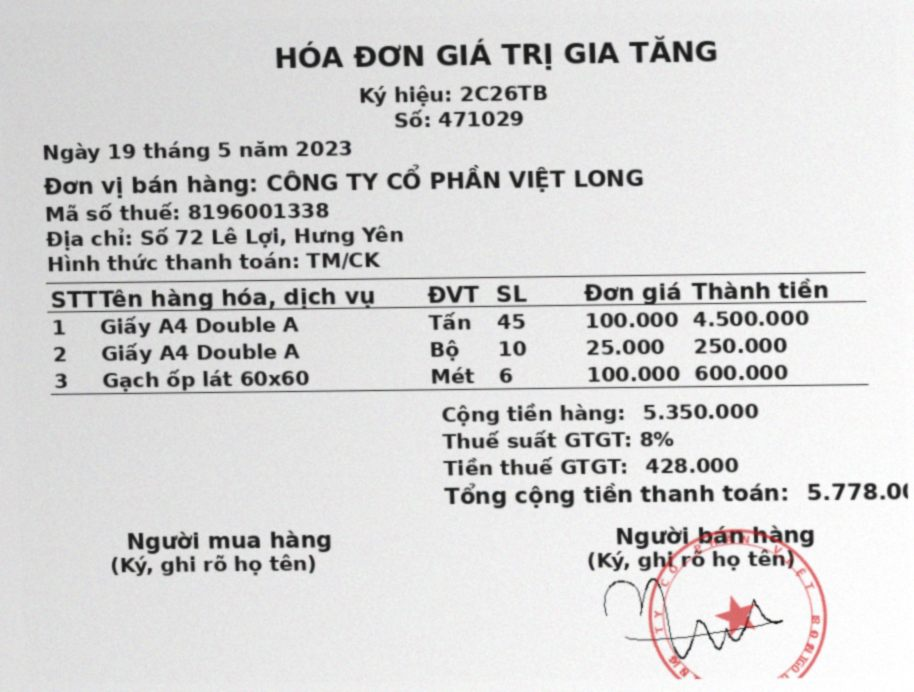

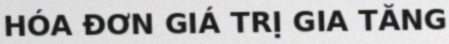

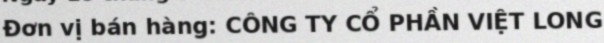

In [7]:
# (tuỳ chọn) Xem thử 1 hóa đơn + vài crop
from PIL import Image; import glob
display(Image.open('dataset/det/images/inv_00001.jpg'))
for f in sorted(glob.glob('dataset/rec/images/inv_00001_*.jpg'))[:5]: display(Image.open(f))


### B.2 — Fine-tune VietOCR (recognition) + lưu Drive


In [8]:
!python training/finetune_vietocr.py --data ./dataset/rec --iters 15000 --batch 32 \
        --out ./weights/vietocr_invoice.pth
!mkdir -p {DRIVE}/weights && cp weights/vietocr_invoice.pth {DRIVE}/weights/ \
 && echo '✅ Đã lưu VietOCR → Drive'


Downloading: "https://download.pytorch.org/models/vgg19_bn-c79401a0.pth" to /root/.cache/torch/hub/checkpoints/vgg19_bn-c79401a0.pth
100% 548M/548M [00:03<00:00, 148MB/s]
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:144: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.encoder = TransformerEncoder(
18533it [00:09, 1897.94it/s]
Create train_invoice: 100%|█████████████████████████████████| 37386/37386 [00:07<00:00, 5261.07it/s]
Created dataset with 37385 samples
train_invoice build cluster: 100%|█████████████████████████| 37385/37385 [00:00<00:00, 69462.36it/s]
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 3 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to cre

### B.3 — Fine-tune PaddleOCR (detection + recognition) + lưu Drive


In [9]:
%cd /content/townhub/ocr-service
!test -d PaddleOCR || git clone --depth 1 https://github.com/PaddlePaddle/PaddleOCR.git


/content
Cloning into 'PaddleOCR'...
remote: Enumerating objects: 2910, done.
remote: Counting objects: 100% (2910/2910), done.
remote: Compressing objects: 100% (2078/2078), done.
remote: Total 2910 (delta 783), reused 2582 (delta 739), pack-reused 0 (from 0)
Receiving objects: 100% (2910/2910), 96.56 MiB | 30.99 MiB/s, done.
Resolving deltas: 100% (783/783), done.
Updating files: 100% (2490/2490), done.


**B.3.1 — Tải model pretrain**


In [10]:
import os; os.chdir('/content/townhub/ocr-service/PaddleOCR'); print('cwd:', os.getcwd())
!mkdir -p pretrain && cd pretrain \
 && wget -q https://paddleocr.bj.bcebos.com/PP-OCRv4/chinese/ch_PP-OCRv4_rec_train.tar \
 && wget -q https://paddleocr.bj.bcebos.com/PP-OCRv4/chinese/ch_PP-OCRv4_det_train.tar \
 && tar xf ch_PP-OCRv4_rec_train.tar && tar xf ch_PP-OCRv4_det_train.tar
!ls pretrain


cwd: /content/townhub/ocr-service/PaddleOCR
ch_PP-OCRv4_det_train	   ch_PP-OCRv4_rec_train
ch_PP-OCRv4_det_train.tar  ch_PP-OCRv4_rec_train.tar


**B.3.2 — Train RECOGNITION**


In [11]:
!python tools/train.py -c configs/rec/PP-OCRv4/PP-OCRv4_rec.yml \
  -o Global.pretrained_model=./pretrain/ch_PP-OCRv4_rec_train/best_accuracy \
     Global.character_dict_path=../dataset/dict_vi.txt \
     Global.use_space_char=True Global.epoch_num=80 \
     Global.save_model_dir=./output/rec_vi \
     Train.dataset.data_dir=../dataset/rec \
     Train.dataset.label_file_list=['../dataset/rec/train.txt'] \
     Eval.dataset.data_dir=../dataset/rec \
     Eval.dataset.label_file_list=['../dataset/rec/val.txt']


Skipping import of the encryption module.
Traceback (most recent call last):
  File "/content/townhub/ocr-service/PaddleOCR/tools/train.py", line 297, in <module>
    config, device, logger, vdl_writer = program.preprocess(is_train=True)
                                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/content/townhub/ocr-service/PaddleOCR/tools/program.py", line 876, in preprocess
    config = load_config(FLAGS.config)
             ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/content/townhub/ocr-service/PaddleOCR/tools/program.py", line 84, in load_config
    config = yaml.load(open(file_path, "rb"), Loader=yaml.SafeLoader)
                       ^^^^^^^^^^^^^^^^^^^^^
FileNotFoundError: [Errno 2] No such file or directory: 'configs/rec/PP-OCRv4/PP-OCRv4_rec.yml'


**B.3.3 — Train DETECTION**


In [12]:
!python tools/train.py -c configs/det/PP-OCRv4/PP-OCRv4_det_student.yml \
  -o Global.pretrained_model=./pretrain/ch_PP-OCRv4_det_train/best_accuracy \
     Global.epoch_num=150 Global.save_model_dir=./output/det_vi \
     Train.dataset.data_dir=../dataset/det \Skipping import of the encryption module.
Traceback (most recent call last):
  File "/content/townhub/ocr-service/PaddleOCR/tools/train.py", line 297, in <module>
    config, device, logger, vdl_writer = program.preprocess(is_train=True)
                                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/content/townhub/ocr-service/PaddleOCR/tools/program.py", line 876, in preprocess
    config = load_config(FLAGS.config)
             ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/content/townhub/ocr-service/PaddleOCR/tools/program.py", line 84, in load_config
    config = yaml.load(open(file_path, "rb"), Loader=yaml.SafeLoader)
                       ^^^^^^^^^^^^^^^^^^^^^
FileNotFoundError: [Errno 2] No such file or directory: 'configs/rec/PP-OCRv4/PP-OCRv4_rec.yml'$0
     Train.dataset.label_file_list=['../dataset/det/train_label.txt'] \
     Eval.dataset.data_dir=../dataset/det \
     Eval.dataset.label_file_list=['../dataset/det/val_label.txt']


Skipping import of the encryption module.
Traceback (most recent call last):
  File "/content/townhub/ocr-service/PaddleOCR/tools/train.py", line 297, in <module>
    config, device, logger, vdl_writer = program.preprocess(is_train=True)
                                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/content/townhub/ocr-service/PaddleOCR/tools/program.py", line 876, in preprocess
    config = load_config(FLAGS.config)
             ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/content/townhub/ocr-service/PaddleOCR/tools/program.py", line 84, in load_config
    config = yaml.load(open(file_path, "rb"), Loader=yaml.SafeLoader)
                       ^^^^^^^^^^^^^^^^^^^^^
FileNotFoundError: [Errno 2] No such file or directory: 'configs/det/PP-OCRv4/PP-OCRv4_det_student.yml'


**B.3.4 — Export inference model + lưu Drive**


In [13]:
!python tools/export_model.py -c configs/rec/PP-OCRv4/PP-OCRv4_rec.yml \
  -o Global.pretrained_model=./output/rec_vi/best_accuracy Global.save_inference_dir=./inference/rec_vi
!python tools/export_model.py -c configs/det/PP-OCRv4/PP-OCRv4_det_student.yml \
  -o Global.pretrained_model=./output/det_vi/best_accuracy Global.save_inference_dir=./inference/det_vi
%cd /content/townhub/ocr-service
!mkdir -p {DRIVE}/inference \
 && cp -r PaddleOCR/inference/rec_vi PaddleOCR/inference/det_vi {DRIVE}/inference/ \
 && cp dataset/dict_vi.txt {DRIVE}/ \
 && echo '✅ Đã lưu Paddle inference + dict → Drive'


Skipping import of the encryption module.
Traceback (most recent call last):
  File "/content/townhub/ocr-service/PaddleOCR/tools/export_model.py", line 37, in <module>
    main()
  File "/content/townhub/ocr-service/PaddleOCR/tools/export_model.py", line 30, in main
    config = load_config(FLAGS.config)
             ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/content/townhub/ocr-service/PaddleOCR/tools/program.py", line 84, in load_config
    config = yaml.load(open(file_path, "rb"), Loader=yaml.SafeLoader)
                       ^^^^^^^^^^^^^^^^^^^^^
FileNotFoundError: [Errno 2] No such file or directory: 'configs/rec/PP-OCRv4/PP-OCRv4_rec.yml'
Skipping import of the encryption module.
Traceback (most recent call last):
  File "/content/townhub/ocr-service/PaddleOCR/tools/export_model.py", line 37, in <module>
    main()
  File "/content/townhub/ocr-service/PaddleOCR/tools/export_model.py", line 30, in main
    config = load_config(FLAGS.config)
             ^^^^^^^^^^^^^^^^^^^^^^^^^
  File 

# 🚀 PHẦN C — CHẠY SERVICE  (khi đã có weight; có thể bỏ qua B)


### C.1 — Kiểm tra weight


In [ ]:
# Kiểm tra weight đã sẵn trên Drive chưa trước khi chạy service.
import os
for k in ['VIETOCR_WEIGHTS','PADDLE_REC_DIR','PADDLE_DET_DIR','PADDLE_REC_DICT']:
    ok = os.path.exists(os.environ[k])
    print(('✅' if ok else '❌ THIẾU'), k, '=', os.environ[k])
print('\nCó ❌ nghĩa là chưa train (chạy phần B) hoặc chưa lưu lên Drive.')


### C.2 — Mở tunnel cloudflared


In [ ]:
# Mở tunnel cloudflared -> URL https công khai để backend .NET gọi vào (đặt vào OCR_SERVICE_URL).
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O /usr/local/bin/cloudflared && chmod +x /usr/local/bin/cloudflared
import subprocess, re
p = subprocess.Popen(['cloudflared','tunnel','--url','http://localhost:7860','--no-autoupdate'],
                     stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
for line in p.stdout:
    print(line, end='')
    m = re.search(r'https://[-a-z0-9]+\.trycloudflare\.com', line)
    if m: print('\n🌐 OCR_SERVICE_URL =', m.group(0)); break


### C.3 — Chạy service *(giữ cell này chạy)*
Đặt `OCR_SERVICE_URL` phía backend .NET = URL cloudflared ở C.2, `OCR_API_KEY` = `OCRKEY`.


In [ ]:
!python app.py
